In [4]:
import tensorflow as tf
import numpy as np

I0000 00:00:1776039390.597682   22457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776039390.629541   22457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776039391.549595   22457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
tf.config.list_physical_devices('GPU')

[]

E0000 00:00:1776039392.047545   22457 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
def categorize_labels(label: float) -> float:
    if label < 0.3: # Low Volatility
        return 0.0
    if label < 0.5: # Medium Volatility
        return 1.0
    if label < 0.6: # High Volatility
        return 2.0
    
    return 3.0 # Very High Volatility

In [15]:
data = np.loadtxt('stock_curated.csv', delimiter=',')
data = data.T
np.random.shuffle(data)
data = data.T

In [16]:
X = data[:252,:]
raw_Y = np.array(data[-1:,:])
Y = (tf.keras.utils.to_categorical(np.vectorize(categorize_labels)(raw_Y), 4)).T

In [17]:
Y.shape = (Y.shape[0], Y.shape[1])
print(X.shape)
print(Y.shape)

(252, 74389)
(4, 74389)


In [18]:
print("Low Volatility:", np.count_nonzero(Y[0]))
print("Medium Volatility:", np.count_nonzero(Y[1]))
print("High Volatility:", np.count_nonzero(Y[2]))
print("Very High Volatility:", np.count_nonzero(Y[3]))

Low Volatility: 4430
Medium Volatility: 40739
High Volatility: 18743
Very High Volatility: 10477


In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer='glorot_uniform', input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(252, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer='glorot_uniform'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(252, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    #tf.keras.layers.Reshape((252,1)),
    #tf.keras.layers.LSTM(252, activation='tanh', recurrent_activation='relu', kernel_initializer='he_normal'),
    #tf.keras.layers.Reshape((512, 1)),
    #tf.keras.layers.Conv1D(filters=30, kernel_size=7, activation='relu', padding='same'),
    #tf.keras.layers.Reshape((14,1)),
    #tf.keras.layers.MaxPooling1D(pool_size=2),
    #tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(4, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,012 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,068 (1015.89 KB)

 Trainable params: 258,052 (1008.02 KB)

 Non-trainable params: 2,016 (7.88 KB)

In [12]:
train_size = int(data.shape[1] * 0.8)

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(59511, 252)
(59511, 4)
(14878, 252)
(14878, 4)


In [13]:
model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=300,
                  verbose=1,
                  shuffle=True)

Epoch 1/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5475 - loss: 1.0882 - val_accuracy: 0.5280 - val_loss: 1.0746
Epoch 2/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6064 - loss: 0.9285 - val_accuracy: 0.5471 - val_loss: 1.0218
Epoch 3/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6164 - loss: 0.8966 - val_accuracy: 0.5683 - val_loss: 0.9629
Epoch 4/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6252 - loss: 0.8776 - val_accuracy: 0.5677 - val_loss: 0.9690
Epoch 5/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6317 - loss: 0.8600 - val_accuracy: 0.5834 - val_loss: 0.9483
Epoch 6/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6376 - loss: 0.8458 - val_accuracy: 0.5760 - val_loss: 0.9312
Epoch 7/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6457 - loss: 0.8300 - val_accuracy: 0.6320 - val_loss: 0.8816
Epoch 8/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6503 - loss: 0.8178 - val_accu

KeyboardInterrupt: 

In [100]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['accuracy']) + 1))
    plt.plot(xs, history.history['accuracy'], label="Model Accuracy", color="Red")
    plt.plot(xs, history.history['val_accuracy'], label="Validation Accuracy", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

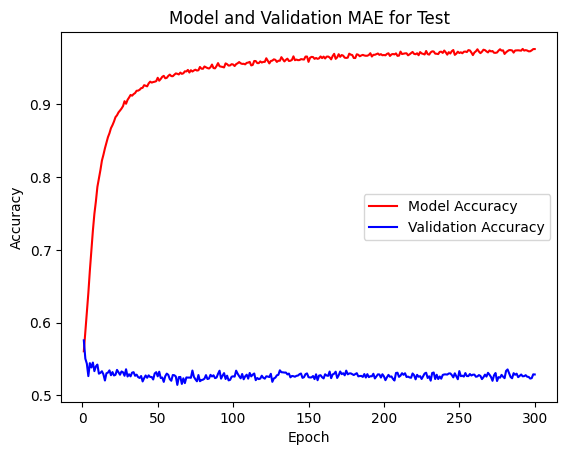

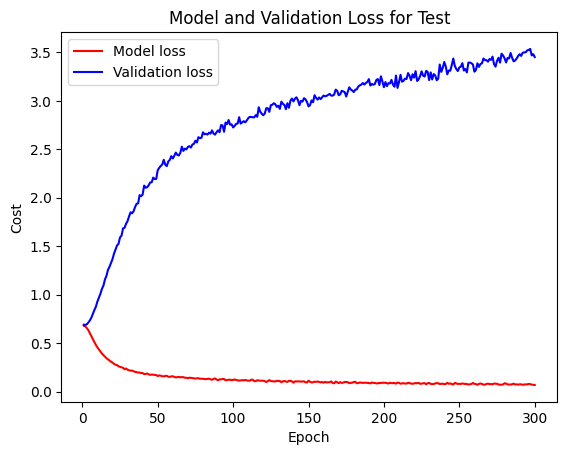

In [101]:
plot_acc_and_loss(model.history, "Test")

In [102]:
print("Prediction:", model(X_val[5:10]))
print("Label:", Y_val[5:10])

Prediction: tf.Tensor(
[[9.9999678e-01 3.1685800e-06]
 [9.9621981e-01 3.7801582e-03]
 [4.8464304e-04 9.9951541e-01]
 [2.5733770e-04 9.9974269e-01]
 [6.6386998e-01 3.3613002e-01]], shape=(5, 2), dtype=float32)
Label: [[1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
